In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_data = pd.read_csv("sample_data/train.csv")
train_data.keys()

Index(['Пол', 'Дата рождения', 'Онкологический диагноз',
       'Дата постановки онкологического диагноза / начала первичного лечения',
       'Дата удаления первичного очага', 'Дата развития МГМ',
       'Активирующие мутации', 'Дата проведения ОВГМ', 'Дата операции на ГМ',
       'Число РХ процедур на ГН', 'Дата 1-ой РХ', 'Индекс Карновского',
       'Число очагов в ГМ', 'Суммарный объем очагов',
       'Объем максимального очага', 'Экстракраниальные метастазы',
       'Лекарственное лечение', 'Локальный рецидив', 'Дистантные метастазы',
       'Интракраниальная прогрессия'],
      dtype='object')

In [ ]:
for i in train_data.keys():
  print(train_data[i].value_counts())

Пол
Ж    492
М    351
ж     19
м     10
Name: count, dtype: int64
Дата рождения
15.01.1947    3
17.01.1966    2
28.02.1956    2
14.07.1956    2
30.03.1959    2
             ..
11.04.1960    1
11.04.1972    1
11.04.1974    1
11.05.1954    1
10.11.1962    1
Name: count, Length: 843, dtype: int64
Онкологический диагноз
РМЖ         263
НМРЛ        229
Меланома    188
РП          128
КРР          64
Name: count, dtype: int64
Дата постановки онкологического диагноза / начала первичного лечения
01.12.2008    34
01.12.2009    25
01.12.2011    25
01.12.2013    22
01.12.2012    22
              ..
19.03.2003     1
30.04.2015     1
01.01.2006     1
29.12.2010     1
26.03.1999     1
Name: count, Length: 323, dtype: int64
Дата удаления первичного очага
не удален     91
01.12.2008    21
01.12.2009    17
01.12.2011    14
01.12.2003    12
              ..
08.04.2014     1
01.10.2006     1
01.02.2007     1
13.05.2011     1
01.07.2007     1
Name: count, Length: 250, dtype: int64
Дата развития МГМ
01.10.

In [ ]:
train_data

,Пол,Дата рождения,Онкологический диагноз,Дата постановки онкологического диагноза / начала первичного лечения,Дата удаления первичного очага,Дата развития МГМ,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,Дата 1-ой РХ,Индекс Карновского,Число очагов в ГМ,Суммарный объем очагов,Объем максимального очага,Экстракраниальные метастазы,Лекарственное лечение,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия
0,М,04.06.1947,НМРЛ,01.04.2008,NaN,01.05.2009,NaN,нет,NaN,1,10.11.2009,70,1,"6,20","6,20",NaN,Химиотерапия,нет,нет,нет
1,М,13.03.1951,РП,01.12.1992,NaN,01.05.2008,NaN,NaN,01.05.2008,3,21.03.2013,70,1,"0,36","0,36",NaN,Таргетная терапия,10.04.2014,10.04.2014,ЛР+ДМ
2,М,21.06.1957,Меланома,01.02.2008,01.02.2008,01.06.2009,NaN,нет,нет,1,08.10.2009,80,3,"0,42","0,37",есть,Химиотерапия,нет,#REF!,ДМ
3,М,24.02.1959,НМРЛ,01.12.2013,не удален,30.05.2014,NaN,NaN,NaN,1,14.07.2014,60,4,"6,39","5,47",есть,Химиотерапия,нет,нет,нет
4,Ж,19.12.1961,КРР,29.12.2010,29.12.2010,01.09.2013,NaN,NaN,01.09.2013,1,26.02.2015,80,3,"5,50","4,62",есть,Таргетная терапия,нет,нет,нет
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,М,31.07.1980,Меланома,01.01.2010,01.01.2010,01.03.2010,NaN,нет,нет,1,01.04.2010,70,12,"9,58","4,20",есть,NaN,нет,нет,нет
868,Ж,31.08.1945,НМРЛ,NaN,NaN,NaN,есть,18.04.2012,нет,1,10.04.2012,80,14,"18,82","7,68",есть,Таргетная терапия,нет,нет,нет
869,Ж,31.08.1953,РП,01.07.2007,01.07.2007,01.12.2008,NaN,нет,нет,1,11.01.2009,70,4,"2,46","1,90",есть,Таргетная терапия,нет,нет,нет
870,Ж,31.12.1946,РМЖ,01.12.2004,NaN,01.11.2006,нет,01.12.2006,01.12.2006,1,08.02.2008,80,8,"9,69","4,80",есть,Химиотерапия,нет,нет,нет


In [ ]:
srt = "Дата 1-ой РХ"
train_data['Дата рождения'] = pd.to_datetime(train_data['Дата рождения'], format = "%d.%m.%Y")
train_data[srt] = pd.to_datetime(train_data[srt], format = "%d.%m.%Y")

train_data['Возраст на момент СРТ (лет)'] = (train_data[srt] - train_data['Дата рождения']).dt.days // 365.25

In [ ]:
srt = "Дата 1-ой РХ"
mgm = "Дата развития МГМ"

train_data[mgm] = pd.to_datetime(train_data[mgm], format = "%d.%m.%Y",  errors='coerce')
train_data[srt] = pd.to_datetime(train_data[srt], format = "%d.%m.%Y",  errors='coerce')

train_data['Время реагирования (дни)'] = (train_data[srt] - train_data[mgm]).dt.days


In [ ]:
pos = "Дата постановки онкологического диагноза / начала первичного лечения"
mgm = "Дата развития МГМ"

train_data[mgm] = pd.to_datetime(train_data[mgm], format = "%d.%m.%Y",  errors='coerce')
train_data[pos] = pd.to_datetime(train_data[pos], format = "%d.%m.%Y",  errors='coerce')

train_data['Время метастазирования (дни)'] = (train_data[mgm] - train_data[pos]).dt.days


In [ ]:
#Обработка данных

#Обработка на отрицательные значения времени реагирования и времени метастазирования
train_data.loc[train_data['Время реагирования (дни)'] < 0, 'Время реагирования (дни)'] = np.nan

#Изменение ошибок в поле
train_data['Пол'] = train_data['Пол'].str.upper()
info_pol = train_data["Пол"].value_counts()

# Удаление строк, где "Интракраниальная прогрессия" не заполнена (NaN)
train_data = train_data.dropna(subset=["Интракраниальная прогрессия"]).copy()

# Все виды значений в "Интракраниальная прогрессия"
display(train_data["Интракраниальная прогрессия"].value_counts())

# Определение ожидаемого значения для столбца "Интракраниальная прогрессия"
def determine_expected_ip(local, distant):
    # Проверяем, есть ли локальный рецидив
    has_local = isinstance(local, str) and local != "нет"
    # Проверяем, есть ли дистантные метастазы
    has_distant = isinstance(distant, str) and distant != "нет"

    if has_local and has_distant:
        return "ЛР+ДМ"
    elif has_local:
        return "ЛР"
    elif has_distant:
        return "ДМ"
    else:
        return "нет"

# Применяем функцию к каждой строке DataFrame для определения ожидаемого значения
train_data["Ожидаемая прогрессия"] = train_data.apply(
    lambda row: determine_expected_ip(row["Локальный рецидив"], row["Дистантные метастазы"]),
    axis=1
)

# Вывод ошибок
errors = train_data[train_data["Интракраниальная прогрессия"] != train_data["Ожидаемая прогрессия"]]
if not errors.empty:
    print("\nНайдены ошибки в столбце 'Интракраниальная прогрессия':")
    display(errors[["Локальный рецидив", "Дистантные метастазы", "Интракраниальная прогрессия", "Ожидаемая прогрессия"]])
else:
    print("\nВсе значения в 'Интракраниальная прогрессия' заполнены правильно.")

,count
Интракраниальная прогрессия,
ДМ,279
нет,235
ЛР+ДМ,99
ЛР,67



Найдены ошибки в столбце 'Интракраниальная прогрессия':


,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия,Ожидаемая прогрессия
24,23.11.2009,23.11.2009,ЛР,ЛР+ДМ
51,нет,09.05.2009,нет,ДМ
97,25.07.2013,25.07.2013,ЛР,ЛР+ДМ
104,22.10.2012,нет,нет,ЛР
111,нет,20.12.2016,нет,ДМ
241,15.07.2014,03.04.2013,ДМ,ЛР+ДМ
292,17.07.2017,нет,нет,ЛР
301,#REF!,31.08.2015,ДМ,ЛР+ДМ
361,нет,05.06.2017,нет,ДМ
385,нет,11.10.2017,нет,ДМ


In [ ]:
#Исправление ошибок
train_data.loc[301, "Ожидаемая прогрессия"] = "ДМ"

In [ ]:
train_data

,Пол,Дата рождения,Онкологический диагноз,Дата постановки онкологического диагноза / начала первичного лечения,Дата удаления первичного очага,Дата развития МГМ,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,...,Объем максимального очага,Экстракраниальные метастазы,Лекарственное лечение,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия,Возраст на момент СРТ (лет),Время реагирования (дни),Время метастазирования (дни),Ожидаемая прогрессия
0,М,1947-06-04,НМРЛ,2008-04-01,NaN,2009-05-01,NaN,нет,NaN,1,...,"6,20",NaN,Химиотерапия,нет,нет,нет,62.0,193.0,395.0,нет
1,М,1951-03-13,РП,1992-12-01,NaN,2008-05-01,NaN,NaN,01.05.2008,3,...,"0,36",NaN,Таргетная терапия,10.04.2014,10.04.2014,ЛР+ДМ,62.0,1785.0,5630.0,ЛР+ДМ
2,М,1957-06-21,Меланома,2008-02-01,01.02.2008,2009-06-01,NaN,нет,нет,1,...,"0,37",есть,Химиотерапия,нет,#REF!,ДМ,52.0,129.0,486.0,ДМ
3,М,1959-02-24,НМРЛ,2013-12-01,не удален,2014-05-30,NaN,NaN,NaN,1,...,"5,47",есть,Химиотерапия,нет,нет,нет,55.0,45.0,180.0,нет
4,Ж,1961-12-19,КРР,2010-12-29,29.12.2010,2013-09-01,NaN,NaN,01.09.2013,1,...,"4,62",есть,Таргетная терапия,нет,нет,нет,53.0,543.0,977.0,нет
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866,Ж,1977-07-31,Меланома,2011-05-13,13.05.2011,2013-06-17,есть,06.02.2017,нет,3,...,"0,73",есть,Таргетная терапия,13.01.2014,13.01.2014,ЛР+ДМ,35.0,0.0,766.0,ЛР+ДМ
867,М,1980-07-31,Меланома,2010-01-01,01.01.2010,2010-03-01,NaN,нет,нет,1,...,"4,20",есть,NaN,нет,нет,нет,29.0,31.0,59.0,нет
868,Ж,1945-08-31,НМРЛ,NaT,NaN,NaT,есть,18.04.2012,нет,1,...,"7,68",есть,Таргетная терапия,нет,нет,нет,66.0,NaN,NaN,нет
869,Ж,1953-08-31,РП,2007-07-01,01.07.2007,2008-12-01,NaN,нет,нет,1,...,"1,90",есть,Таргетная терапия,нет,нет,нет,55.0,41.0,519.0,нет


In [ ]:
# тк пол - бинарный признак, поменяем на 0 / 1

train_data['Пол'] = [int(i == 'Ж') for i in train_data['Пол']]
train_data['Пол']

,Пол
0,0
1,0
2,0
3,0
4,1
...,...
866,1
867,0
868,1
869,1


In [ ]:
train_data['Объем максимального очага'] = list(map(lambda x: float(x.replace(',', '.')), train_data['Объем максимального очага']))
train_data['Объем максимального очага']

,Объем максимального очага
0,6.20
1,0.36
2,0.37
3,5.47
4,4.62
...,...
866,0.73
867,4.20
868,7.68
869,1.90


In [ ]:
print("Описание признаков")
print("1. Пол: Пол пациента (мужской/женский). Клиническое значение: пол может влиять на риск развития и прогрессирование заболевания.")
print("2. Возраст на момент СРТ: Возраст пациента в годах на момент проведения СРТ. Клиническое значение: возраст часто связан с дальнейшим прогнозом.")
print("3. Время реагирования (дни): Количество дней между развитием МГМ и проведением СРТ. Клиническое значение: чем быстрее реакция, тем лучше прогноз")


Описание признаков
1. Пол: Пол пациента (мужской/женский). Клиническое значение: пол может влиять на риск развития и прогрессирование заболевания.
2. Возраст на момент СРТ: Возраст пациента в годах на момент проведения СРТ. Клиническое значение: возраст часто связан с дальнейшим прогнозом.
3. Время реагирования (дни): Количество дней между развитием МГМ и проведением СРТ. Клиническое значение: чем быстрее реакция, тем лучше прогноз


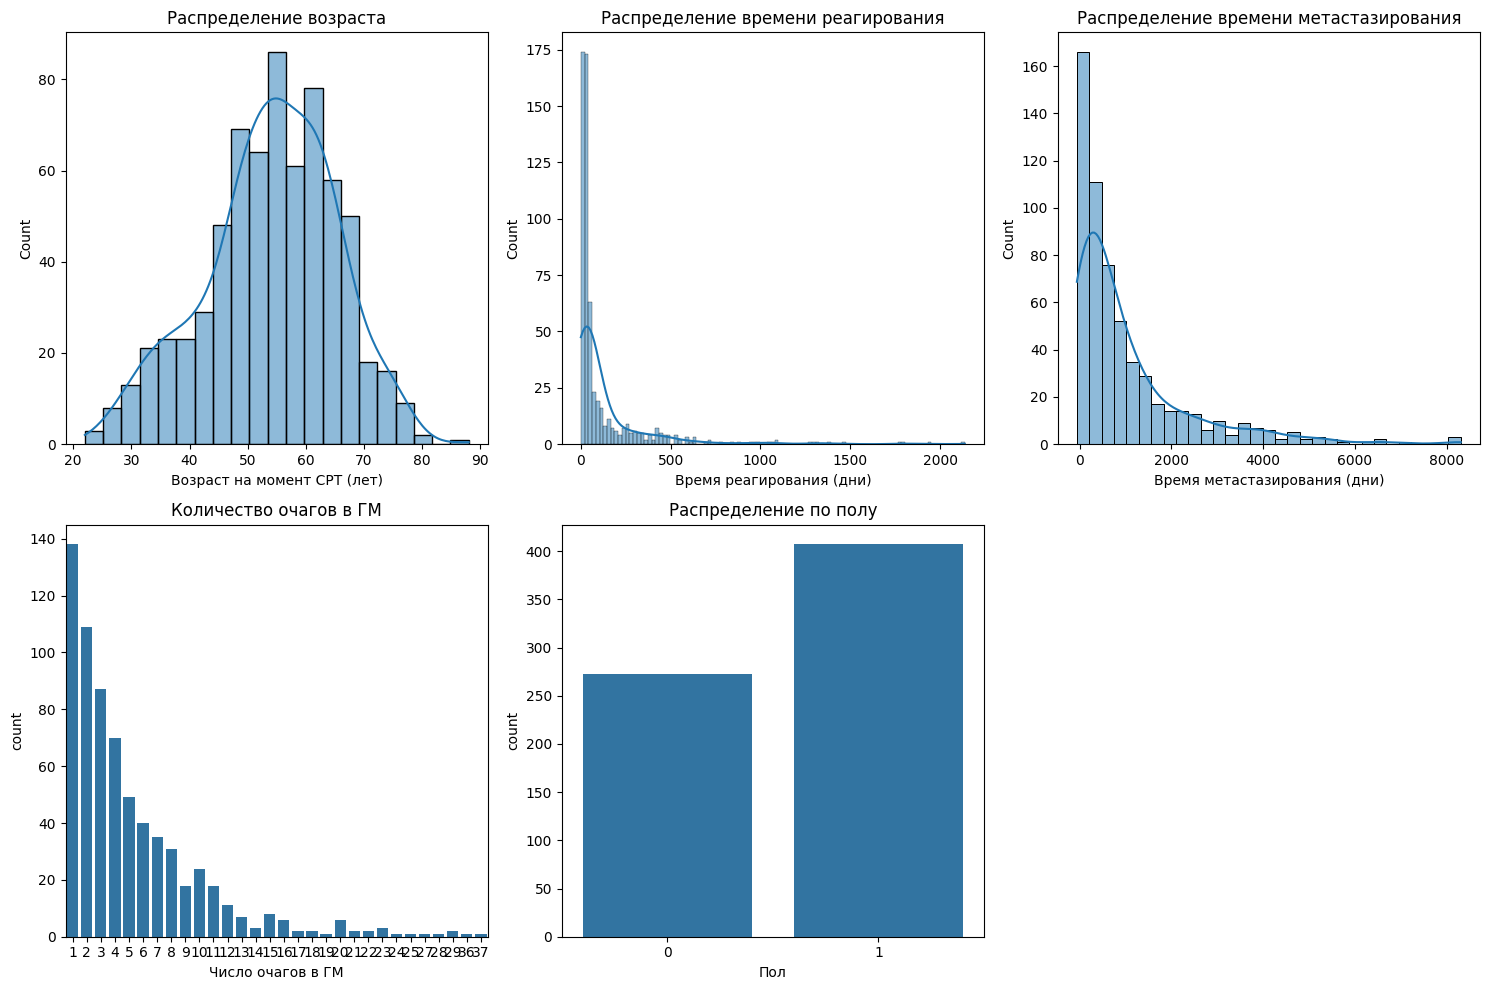

In [ ]:
plt.figure(figsize=(15, 10))

# Распределение возраста
plt.subplot(2, 3, 1)
sns.histplot(train_data['Возраст на момент СРТ (лет)'], kde=True)
plt.title('Распределение возраста')

# Распределение времени реагирования
plt.subplot(2, 3, 2)
sns.histplot(train_data['Время реагирования (дни)'].dropna(), kde=True)
plt.title('Распределение времени реагирования')

# Распределение времени метастазирования
plt.subplot(2, 3, 3)
sns.histplot(train_data['Время метастазирования (дни)'].dropna(), kde=True)
plt.title('Распределение времени метастазирования')

# Количество очагов
plt.subplot(2, 3, 4)
sns.countplot(data=train_data, x='Число очагов в ГМ')
plt.title('Количество очагов в ГМ')

# Пол
plt.subplot(2, 3, 5)
sns.countplot(data=train_data, x='Пол')
plt.title('Распределение по полу')

plt.tight_layout()
plt.show()

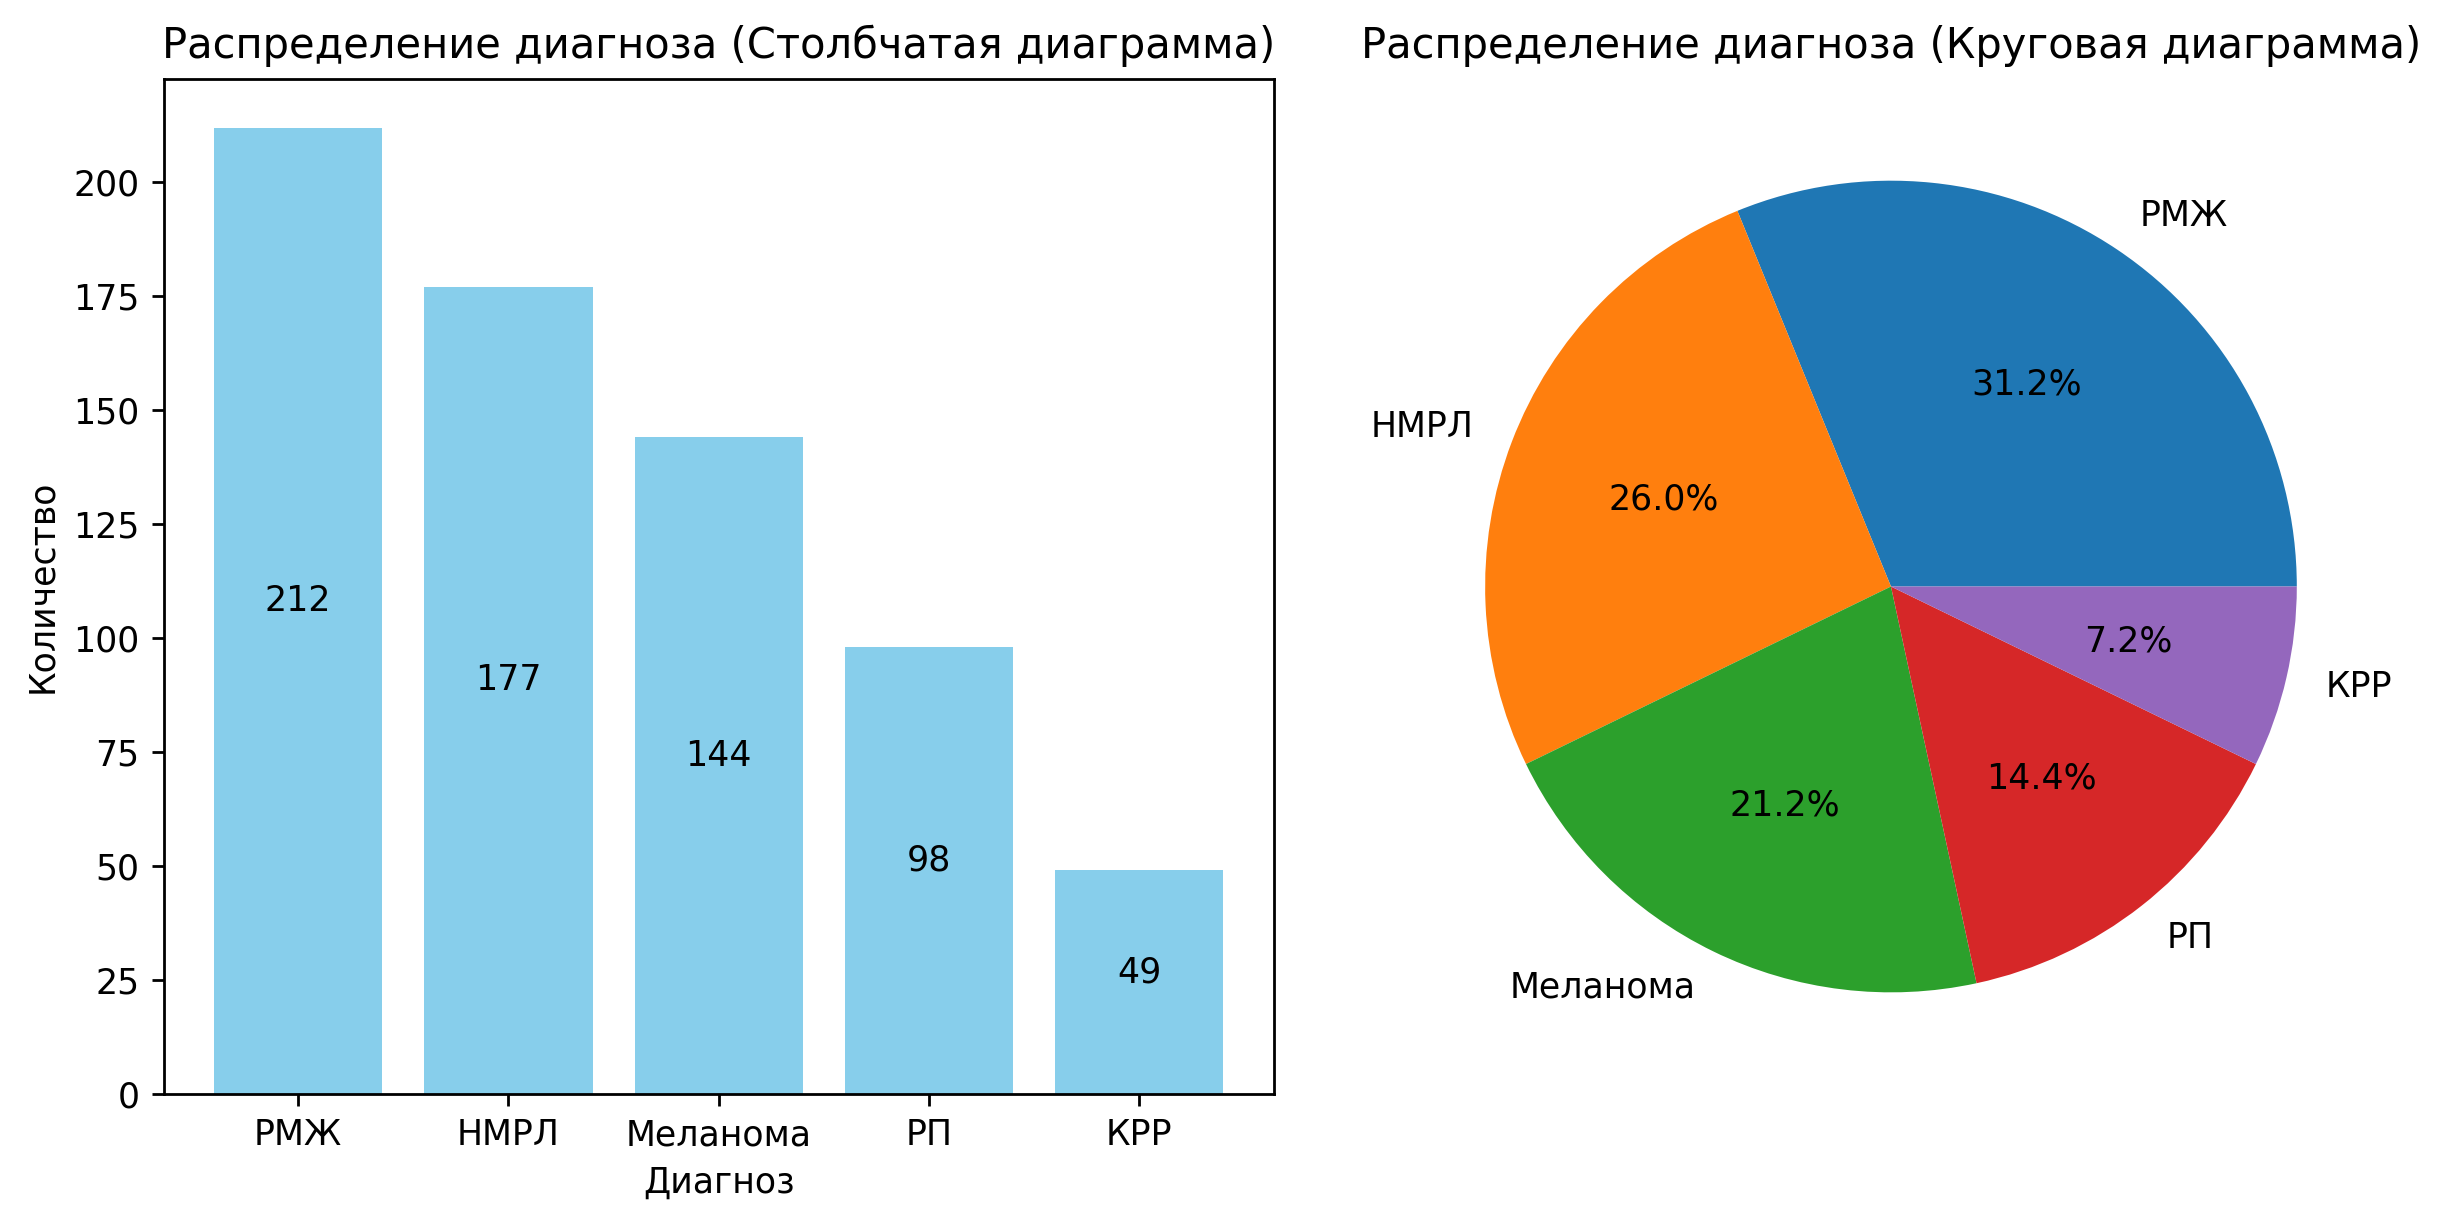

In [ ]:
# Подсчет количества каждого диагноза
diagnosis_counts = train_data['Онкологический диагноз'].value_counts()

# Создание фигуры с двумя подграфиками (1 строка, 2 столбца)
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=250)

# Столбчатая диаграмма
bars = axes[0].bar(
    diagnosis_counts.index,
    diagnosis_counts.values,
    color='skyblue'
  )
for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height/2,
        f'{height}',
        ha='center'
    )
axes[0].set_title('Распределение диагноза (Столбчатая диаграмма)')
axes[0].set_xlabel('Диагноз')
axes[0].set_ylabel('Количество')
axes[0].grid(False)

# Круговая диаграмма
axes[1].pie(
    diagnosis_counts,
    labels=diagnosis_counts.index,
    autopct='%.1f%%'
)
axes[1].set_title('Распределение диагноза (Круговая диаграмма)')

# Автоматическая подгонка подграфиков
plt.tight_layout()

# Отображение графиков
plt.show()

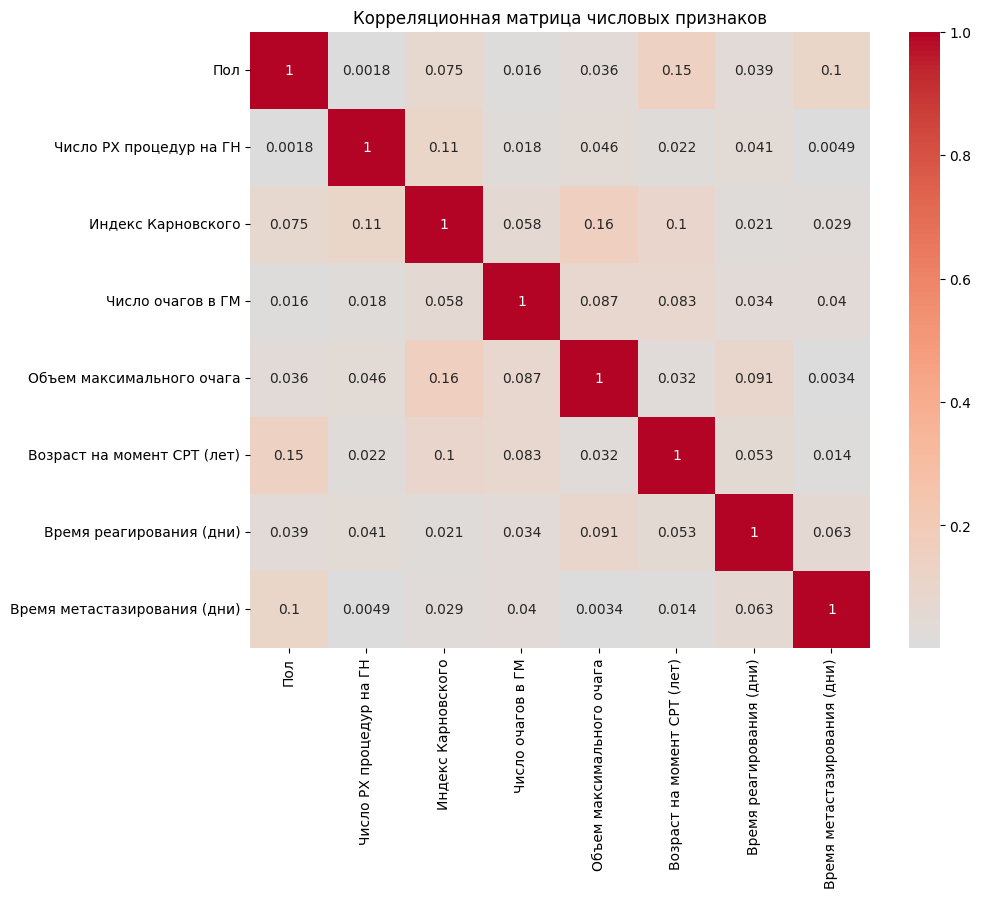

In [ ]:
numeric_cols = train_data.select_dtypes(include=['number']).columns
corr_matrix = train_data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(abs(corr_matrix), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

По семинару-лекции №5

1. Нормазилация x' = (x - x0)/s
где х0 - смещение, оно может быть выбрано ввиде среднего/медианы/(min(x)) - в случаи эскпоненциального, когда начинается не с нуля.

2. про s - стандартизация или z-нормализация. НО ЭТО НЕ ПОДХОДИТ(Вместо нее может использоваться IQR = Q3 - Q1 (из статы). )

В итоге будет использовать разницу между макс и мин (max - min). РАЗМАХ НО ОН ТОЖЕ НЕ ПОДХОДИТ

Короче используем совместную тему, убираем выбросы и дальше смотрим по minmax

Сначала который шаг нормирования, а дальше х'


по желанию либо центрировать, либо с нуля.
для центрирования - медиана или среднее
а для с нуля - min(x)

mc >= 0

с1 = 1.5 * e^(-4mc)
c2 = 1.5 * e^(3mc)

mc < 0

c1 = 1.5 * e^(-3mc)
c2 = 1.5 * e^(4mc)

mc - мера ассиметрии

h(x- , x+ ) (перебор всех возможных комбинаций)



In [ ]:
print("""ТЗ на будущее дз:
1. Пересмотреть выборку данных из семинара с 4-5 недели. Там чуть лучше
2.Сделать несколько функций (для определения с1 и с2)
для ........ tbc
""")

ТЗ на будущее дз:
1. Пересмотреть выборку данных из семинара с 4-5 недели. Там чуть лучше
2.Сделать несколько функций (для определения с1 и с2)
для ........ tbc



In [ ]:
def medcouple(x):
    """
    Вычисление меры асимметрии medcouple (MC)
    возвращает значение medcouple в диапазоне [-1, 1]"""
    x_clean = np.array(x, dtype=float)
    x_clean = x_clean[~np.isnan(x_clean)]

    if len(x_clean) == 0:
        raise ValueError("Нет данных после очистки от NaN")

    x_sorted = np.sort(x_clean)[::-1]
    Q2 = np.median(x_sorted)

    # Разделение на множества X+ и X-
    X_p = x_sorted[x_sorted >= Q2]  # Элементы >= Q2
    X_m = x_sorted[x_sorted <= Q2]  # Элементы <= Q2

    p = len(X_p)
    q = len(X_m)

    # Вычисление функции h() для всех пар
    h_values = []

    for i, x_i in enumerate(X_p):
        for j, x_j in enumerate(X_m):
            if x_i > x_j:
                # Основной случай
                num = (x_i - Q2) - (Q2 - x_j)
                den = x_i - x_j
                h_val = num / den
            else:
                # Случай когда x_i = x_j = Q2
                sign_val = p - 1 - i - j
                if sign_val > 0:
                    h_val = 1.0
                elif sign_val < 0:
                    h_val = -1.0
                else:
                    h_val = 0.0

            h_values.append(h_val)

    # Medcouple - медиана всех значений h
    mc = np.median(h_values)
    return mc

In [ ]:
#изменение границ у бокс-плота
def adjusted_boxplot_bounds(x):
    clean_data = x.dropna().values
    clean_data = clean_data.astype(float)

    # Базовые квартили:
    Q1 = np.quantile(clean_data, 0.25)
    Q3 = np.quantile(clean_data, 0.75)
    IQR = Q3 - Q1

    # Вычисляем асимметрию:
    mc = medcouple(clean_data)
    print(f"Medcouple (асимметрия): {mc:.4f}")

    if mc >= 0:
        lower_bound = 1.5 * (np.exp((-4)*mc))
        upper_bound = 1.5 * (np.exp(3*mc))
    else:
        lower_bound = 1.5 * (np.exp((-3)*mc))
        upper_bound = 1.5 * (np.exp((4)*mc))

    lower = Q1 - lower_bound*IQR
    upper = Q3 + upper_bound*IQR

    return lower, upper

In [ ]:
print(adjusted_boxplot_bounds(train_data["Время реагирования (дни)"]))

Medcouple (асимметрия): 0.7035
(np.float64(11.062185464759004), np.float64(1199.6576739431969))


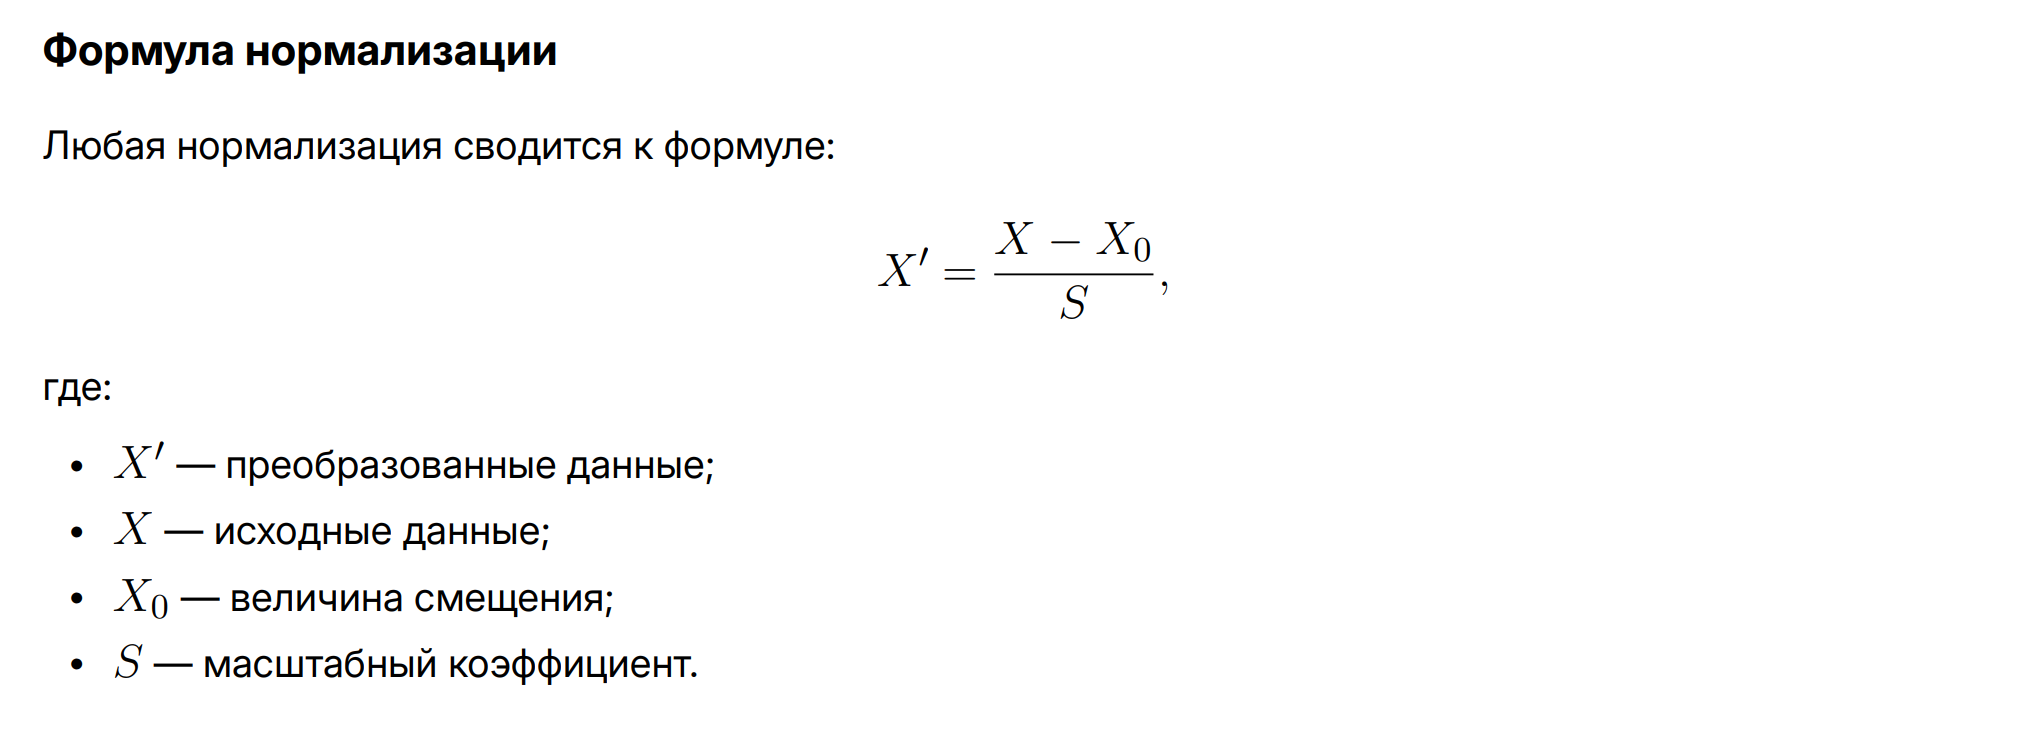

In [ ]:
train_data

,Пол,Дата рождения,Онкологический диагноз,Дата постановки онкологического диагноза / начала первичного лечения,Дата удаления первичного очага,Дата развития МГМ,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,...,Объем максимального очага,Экстракраниальные метастазы,Лекарственное лечение,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия,Возраст на момент СРТ (лет),Время реагирования (дни),Время метастазирования (дни),Ожидаемая прогрессия
0,0,1947-06-04,НМРЛ,2008-04-01,NaN,2009-05-01,NaN,нет,NaN,1,...,6.20,NaN,Химиотерапия,нет,нет,нет,62.0,193.0,395.0,нет
1,0,1951-03-13,РП,1992-12-01,NaN,2008-05-01,NaN,NaN,01.05.2008,3,...,0.36,NaN,Таргетная терапия,10.04.2014,10.04.2014,ЛР+ДМ,62.0,1785.0,5630.0,ЛР+ДМ
2,0,1957-06-21,Меланома,2008-02-01,01.02.2008,2009-06-01,NaN,нет,нет,1,...,0.37,есть,Химиотерапия,нет,#REF!,ДМ,52.0,129.0,486.0,ДМ
3,0,1959-02-24,НМРЛ,2013-12-01,не удален,2014-05-30,NaN,NaN,NaN,1,...,5.47,есть,Химиотерапия,нет,нет,нет,55.0,45.0,180.0,нет
4,1,1961-12-19,КРР,2010-12-29,29.12.2010,2013-09-01,NaN,NaN,01.09.2013,1,...,4.62,есть,Таргетная терапия,нет,нет,нет,53.0,543.0,977.0,нет
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866,1,1977-07-31,Меланома,2011-05-13,13.05.2011,2013-06-17,есть,06.02.2017,нет,3,...,0.73,есть,Таргетная терапия,13.01.2014,13.01.2014,ЛР+ДМ,35.0,0.0,766.0,ЛР+ДМ
867,0,1980-07-31,Меланома,2010-01-01,01.01.2010,2010-03-01,NaN,нет,нет,1,...,4.20,есть,NaN,нет,нет,нет,29.0,31.0,59.0,нет
868,1,1945-08-31,НМРЛ,NaT,NaN,NaT,есть,18.04.2012,нет,1,...,7.68,есть,Таргетная терапия,нет,нет,нет,66.0,NaN,NaN,нет
869,1,1953-08-31,РП,2007-07-01,01.07.2007,2008-12-01,NaN,нет,нет,1,...,1.90,есть,Таргетная терапия,нет,нет,нет,55.0,41.0,519.0,нет


в качестве s - мы берем max(X) - min(X)
x - понятно исходное,  х0 - смещение, оно может быть выбрано ввиде среднего/медианы/(min(x)), но я честно не понял какой самый лучший выбор.

In [ ]:
def normalize(data):
  s0 = adjusted_boxplot_bounds(data)
  print(s0)
  s = s0[1] - s0[0]
  x0 = min(data)
  result = []
  for i in data:
    result.append((i - x0) / s)
  return result

In [ ]:
train_data['Индекс Карновского'] = normalize(train_data['Индекс Карновского'])
train_data['Число РХ процедур на ГН'] = normalize(train_data['Число РХ процедур на ГН'])
train_data['Число очагов в ГМ'] = normalize(train_data['Число очагов в ГМ'])
train_data['Объем максимального очага'] = normalize(train_data['Объем максимального очага'])
train_data['Время реагирования (дни)'] = normalize(train_data['Время реагирования (дни)'])
train_data['Время метастазирования (дни)'] = normalize(train_data['Время метастазирования (дни)'])

Medcouple (асимметрия): 0.0000
(np.float64(40.0), np.float64(120.0))
Medcouple (асимметрия): 1.0000
(np.float64(0.9725265416668988), np.float64(32.1283053847815))
Medcouple (асимметрия): 0.3333
(np.float64(0.023021464132049196), np.float64(27.38711371344284))
Medcouple (асимметрия): 0.3378
(np.float64(-0.5570789747852838), np.float64(29.889654903239695))
Medcouple (асимметрия): 0.7035
(np.float64(11.062185464759004), np.float64(1199.6576739431969))
Medcouple (асимметрия): 0.4771
(np.float64(-108.26621525339277), np.float64(8665.813072037763))


In [ ]:
train_data

,Пол,Дата рождения,Онкологический диагноз,Дата постановки онкологического диагноза / начала первичного лечения,Дата удаления первичного очага,Дата развития МГМ,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,...,Объем максимального очага,Экстракраниальные метастазы,Лекарственное лечение,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия,Возраст на момент СРТ (лет),Время реагирования (дни),Время метастазирования (дни),Ожидаемая прогрессия
0,0,1947-06-04,НМРЛ,2008-04-01,NaN,2009-05-01,NaN,нет,NaN,0.000000,...,0.202321,NaN,Химиотерапия,нет,нет,нет,62.0,0.162377,0.052085,нет
1,0,1951-03-13,РП,1992-12-01,NaN,2008-05-01,NaN,NaN,01.05.2008,0.064194,...,0.010510,NaN,Таргетная терапия,10.04.2014,10.04.2014,ЛР+ДМ,62.0,1.501772,0.648729,ЛР+ДМ
2,0,1957-06-21,Меланома,2008-02-01,01.02.2008,2009-06-01,NaN,нет,нет,0.000000,...,0.010839,есть,Химиотерапия,нет,#REF!,ДМ,52.0,0.108531,0.062457,ДМ
3,0,1959-02-24,НМРЛ,2013-12-01,не удален,2014-05-30,NaN,NaN,NaN,0.000000,...,0.178344,есть,Химиотерапия,нет,нет,нет,55.0,0.037860,0.027581,нет
4,1,1961-12-19,КРР,2010-12-29,29.12.2010,2013-09-01,NaN,NaN,01.09.2013,0.000000,...,0.150427,есть,Таргетная терапия,нет,нет,нет,53.0,0.456842,0.118417,нет
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866,1,1977-07-31,Меланома,2011-05-13,13.05.2011,2013-06-17,есть,06.02.2017,нет,0.064194,...,0.022663,есть,Таргетная терапия,13.01.2014,13.01.2014,ЛР+ДМ,35.0,0.000000,0.094369,ЛР+ДМ
867,0,1980-07-31,Меланома,2010-01-01,01.01.2010,2010-03-01,NaN,нет,нет,0.000000,...,0.136632,есть,NaN,нет,нет,нет,29.0,0.026081,0.013791,нет
868,1,1945-08-31,НМРЛ,NaT,NaN,NaT,есть,18.04.2012,нет,0.000000,...,0.250930,есть,Таргетная терапия,нет,нет,нет,66.0,NaN,NaN,нет
869,1,1953-08-31,РП,2007-07-01,01.07.2007,2008-12-01,NaN,нет,нет,0.000000,...,0.061090,есть,Таргетная терапия,нет,нет,нет,55.0,0.034494,0.066218,нет


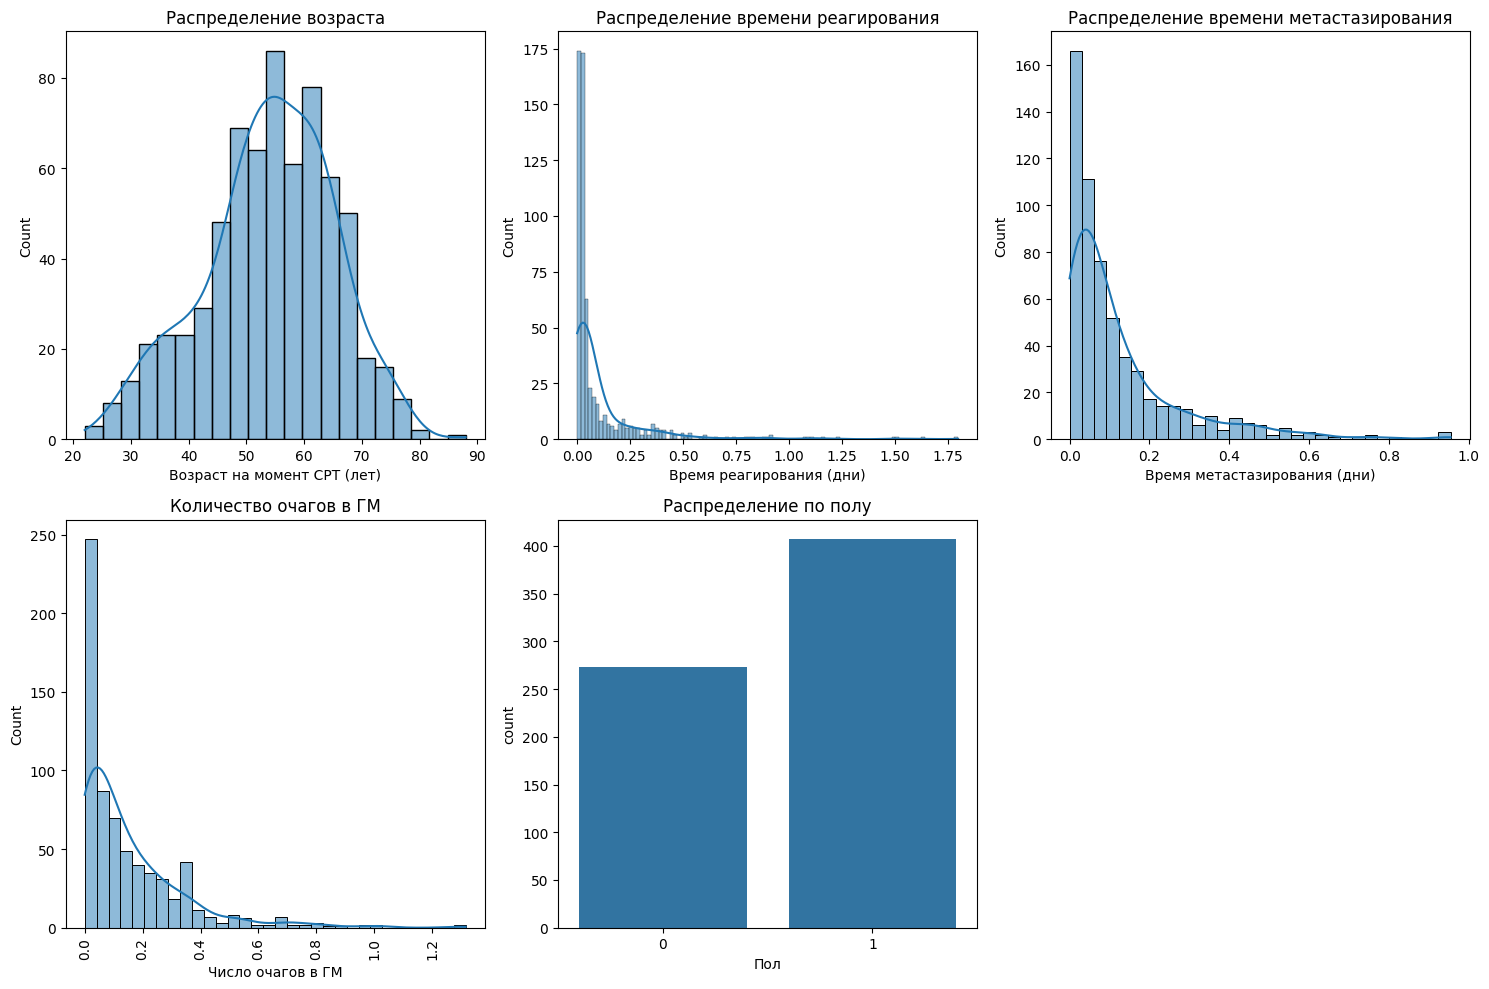

In [ ]:
plt.figure(figsize=(15, 10))

# Распределение возраста
plt.subplot(2, 3, 1)
sns.histplot(train_data['Возраст на момент СРТ (лет)'], kde=True)
plt.title('Распределение возраста')

# Распределение времени реагирования
plt.subplot(2, 3, 2)
sns.histplot(train_data['Время реагирования (дни)'].dropna(), kde=True)
plt.title('Распределение времени реагирования')

# Распределение времени метастазирования
plt.subplot(2, 3, 3)
sns.histplot(train_data['Время метастазирования (дни)'].dropna(), kde=True)
plt.title('Распределение времени метастазирования')

# Количество очагов
plt.subplot(2, 3, 4)
sns.histplot(data=train_data, x='Число очагов в ГМ', kde = True)
plt.xticks(rotation=90)
plt.title('Количество очагов в ГМ')

# Пол
plt.subplot(2, 3, 5)
sns.countplot(data=train_data, x='Пол')
plt.title('Распределение по полу')

plt.tight_layout()
plt.show()

In [ ]:
# Приведение болезни в бинарное состояние
train_data['Диагноз НМРЛ'] = np.where(train_data['Онкологический диагноз'] == "НМРЛ", 1, 0)
train_data['Диагноз РП'] = np.where(train_data['Онкологический диагноз'] == "РП", 1, 0)
train_data['Диагноз Меланома'] = np.where(train_data['Онкологический диагноз'] == "Меланома", 1, 0)
train_data['Диагноз КРР'] = np.where(train_data['Онкологический диагноз'] == "КРР", 1, 0)
train_data['Диагноз РМЖ'] = np.where(train_data['Онкологический диагноз'] == "РМЖ", 1, 0)

train_data['Активирующие мутации'] = train_data['Активирующие мутации'].replace("нет", "0").replace("да", "1")

train_data['Экстракраниальные метастазы'] = train_data['Экстракраниальные метастазы'].replace("нет", "0").replace("да", "1")

train_data['Лекарственное лечение химиотерапией'] = np.where(train_data['Лекарственное лечение'] == "Химиотерапия", 1, 0)
train_data['Лекарственное лечение таргетной терапией'] = np.where(train_data['Лекарственное лечение'] == "Таргетная терапия", 1, 0)
train_data['Без лекарственного лечения'] = np.where(train_data['Лекарственное лечение'] == "Без лечения", 1, 0)

In [ ]:
print(train_data["Лекарственное лечение"].unique())
print(train_data["Экстракраниальные метастазы"].unique())



['Химиотерапия' 'Таргетная терапия' nan 'Без лечения']
[nan 'есть' '0']


In [ ]:
# train_data
# for i in train_data.keys():
#   print(train_data[i].value_counts())

ТЗ
в столбцах, где даты, значения "нет" изменить на nan, чтобы при обучении модели оно определялось как DateTime, а также изменить дату с . на -. Не удален толже изменить на nan

In [ ]:
train_data["Дата проведения ОВГМ"] = train_data["Дата проведения ОВГМ"].replace("нет", pd.NA)

## ДЗ 7

In [ ]:
train_data

,Пол,Дата рождения,Онкологический диагноз,Дата постановки онкологического диагноза / начала первичного лечения,Дата удаления первичного очага,Дата развития МГМ,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,...,Время метастазирования (дни),Ожидаемая прогрессия,Диагноз НМРЛ,Диагноз РП,Диагноз Меланома,Диагноз КРР,Диагноз РМЖ,Лекарственное лечение химиотерапией,Лекарственное лечение таргетной терапией,Без лекарственного лечения
0,0,1947-06-04,НМРЛ,2008-04-01,NaN,2009-05-01,NaN,<NA>,NaN,0.000000,...,0.052085,нет,1,0,0,0,0,1,0,0
1,0,1951-03-13,РП,1992-12-01,NaN,2008-05-01,NaN,NaN,01.05.2008,0.064194,...,0.648729,ЛР+ДМ,0,1,0,0,0,0,1,0
2,0,1957-06-21,Меланома,2008-02-01,01.02.2008,2009-06-01,NaN,<NA>,нет,0.000000,...,0.062457,ДМ,0,0,1,0,0,1,0,0
3,0,1959-02-24,НМРЛ,2013-12-01,не удален,2014-05-30,NaN,NaN,NaN,0.000000,...,0.027581,нет,1,0,0,0,0,1,0,0
4,1,1961-12-19,КРР,2010-12-29,29.12.2010,2013-09-01,NaN,NaN,01.09.2013,0.000000,...,0.118417,нет,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866,1,1977-07-31,Меланома,2011-05-13,13.05.2011,2013-06-17,есть,06.02.2017,нет,0.064194,...,0.094369,ЛР+ДМ,0,0,1,0,0,0,1,0
867,0,1980-07-31,Меланома,2010-01-01,01.01.2010,2010-03-01,NaN,<NA>,нет,0.000000,...,0.013791,нет,0,0,1,0,0,0,0,0
868,1,1945-08-31,НМРЛ,NaT,NaN,NaT,есть,18.04.2012,нет,0.000000,...,NaN,нет,1,0,0,0,0,0,1,0
869,1,1953-08-31,РП,2007-07-01,01.07.2007,2008-12-01,NaN,<NA>,нет,0.000000,...,0.066218,нет,0,1,0,0,0,0,1,0


In [ ]:
# Разделение признаков на числовые и категориальные
numerical_features = ['Число очагов', 'Объем очагов', 'Число РХ процедур',
                        'Индекс Карновского', 'Возраст', 'Время метастазирования',
                        'Время реагирования']
categorical_features = ['ОВГМ', 'Операция', 'КРР', 'Меланома', 'НМРЛ',
                        'РМЖ', 'РП', 'Таргетная терапия', 'Химиотерапия',
                        'Без лечения', 'Мужчина']
target = 'Прогрессия'